# Ground Truth Creation Pipeline

This notebook keeps the original project paths unchanged and updates the pipeline around the two files you already have:

- `D:\Saqib\Footprint_Extraction\GroundTruth\Building_xml`
- `D:\Saqib\Footprint_Extraction\GroundTruth\cache\all_footprints.gpkg`

The main optimizations are:

- use the existing GeoPackage cache first,
- fall back to XML only if the cache is missing,
- use fast GPKG I/O when `pyogrio` is available,
- cache repeated polygon point counts,
- use `itertuples()` instead of `iterrows()`,
- optionally parallelize per-building export with threads,
- include preview / validation visualizations,
- keep the original export structure and paths.

## Pipeline summary

1. Load the tile LAS/LAZ.
2. Load footprints near the tile from `all_footprints.gpkg`.
3. Apply spatial / temporal / status filters.
4. Keep building-class points only.
5. Estimate the density threshold from sampled footprints.
6. Filter footprints by density.
7. Export each footprint as LAS + SHP + GPKG.
8. Save an export log and preview plots.

In [ ]:
# ==========================================
# Set your absolute base directory here.
# For publication/others, this can be f"{BASE_DIR}/"
# ==========================================
import os
BASE_DIR = r"D:\Saqib\Footprint_Extraction"

import os
import glob
import re
import shutil
import warnings
import time
from datetime import datetime, timedelta
from concurrent.futures import ThreadPoolExecutor, as_completed
import numpy as np
import pandas as pd
import geopandas as gpd
import laspy
import matplotlib.pyplot as plt
from shapely.geometry import Point, box
from tqdm.auto import tqdm
warnings.filterwarnings("ignore")
# -------------------------------------------------------------------
# Project folders: keep these paths unchanged
# -------------------------------------------------------------------
POINT_TILES_DIR = f"{BASE_DIR}/GroundTruth/point_tiles"
BUILDING_XML_DIR = f"{BASE_DIR}/GroundTruth/Building_xml"
CACHE_DIR = f"{BASE_DIR}/GroundTruth/cache"
REFINE_FILES_DIR = f"{BASE_DIR}/GroundTruth/refine_files_building_extraction_pipeline"
LOG_DIR = f"{BASE_DIR}/GroundTruth/logs"
MASTER_GPKG = os.path.join(CACHE_DIR, "all_footprints.gpkg")
CACHE_LAYER_NAME = "all_footprints"
# -------------------------------------------------------------------
# Tile input: set this to the LAZ tile you want to process
# -------------------------------------------------------------------
TILE_LAZ_FILE = f"{BASE_DIR}/laz_obj files/Footprint Extraction Laz Files/21FZ1_01.LAZ"
# -------------------------------------------------------------------
# Pipeline controls
# -------------------------------------------------------------------
CLASS_BUILDINGS = 6
GPKG_BBOX_BUFFER_M = 50
AHN3_DATE = datetime(2021, 8, 3)
DATE_TOLERANCE_DAYS = 30
DATE_MIN = AHN3_DATE - timedelta(days=DATE_TOLERANCE_DAYS)
DATE_MAX = AHN3_DATE + timedelta(days=DATE_TOLERANCE_DAYS)
ENABLE_SPATIAL_FILTER = True
ENABLE_TEMPORAL_FILTER = True
ENABLE_STATUS_FILTER = True
ENABLE_DENSITY_FILTER = True
DENSITY_RATIO = 0.80
DENSITY_SAMPLE_SIZE = 300
MIN_FOOTPRINT_AREA_M2 = 15.0
EXPORT_LAS = True
EXPORT_SHP = True
EXPORT_GPKG = True
EXPORT_LOG_CSV = True
# Optional cleanup / renumbering
ENABLE_RENUMBERING = False
RENUMBER_START_NUMBER = 1
# -------------------------------------------------------------------
# Optimizations
# -------------------------------------------------------------------
USE_FAST_VECTOR_IO = True          # pyogrio if available
USE_COUNT_CACHE = True             # cache repeated polygon point counts
PARALLEL_BUILDING_EXPORT = True    # thread-based export
EXPORT_WORKERS = min(8, (os.cpu_count() or 4))
ENABLE_PREVIEW_PLOTS = True
PREVIEW_SAMPLE_BUILDINGS = 3
PREVIEW_MAX_POINTS = 250_000
# -------------------------------------------------------------------
# Create folders if they do not exist
# -------------------------------------------------------------------
os.makedirs(CACHE_DIR, exist_ok=True)
os.makedirs(REFINE_FILES_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)
print("Configuration loaded.")
print(f"Tile input: {TILE_LAZ_FILE}")
print(f"Cache file: {MASTER_GPKG}")
print(f"Output root: {REFINE_FILES_DIR}")
print(f"Parallel export workers: {EXPORT_WORKERS}")

Configuration loaded.
Tile input: D:\Saqib\Footprint_Extraction\laz_obj files\Footprint Extraction Laz Files\21FZ1_01.LAZ
Cache file: D:\Saqib\Footprint_Extraction\GroundTruth\cache\all_footprints.gpkg
Output root: D:\Saqib\Footprint_Extraction\GroundTruth\refine_files_building_extraction_pipeline
Parallel export workers: 8


In [5]:
def safe_remove(path):
    """Remove a file if it exists."""
    if path and os.path.exists(path):
        os.remove(path)
def safe_remove_shapefile(base_path):
    """
    Remove all files that belong to a shapefile base name.
    Example base_path = .../building_001
    """
    for ext in [".shp", ".shx", ".dbf", ".prj", ".cpg", ".qpj", ".fix"]:
        path = base_path + ext
        if os.path.exists(path):
            os.remove(path)
def prepare_output_dir(tile_name):
    """
    Create a dedicated output directory for the tile.
    The final folder will contain one file set per building.
    """
    output_dir = os.path.join(REFINE_FILES_DIR, f"matched_buildings_{tile_name}")
    os.makedirs(output_dir, exist_ok=True)
    return output_dir
def load_tile_laz(tile_path):
    """Load a single LAZ/LAS tile and return the file plus its X/Y/Z coordinates."""
    if not os.path.exists(tile_path):
        raise FileNotFoundError(f"Tile not found: {tile_path}")
    print(f"Loading tile: {tile_path}")
    las = laspy.read(tile_path)
    x = np.asarray(las.x)
    y = np.asarray(las.y)
    z = np.asarray(las.z)
    print(f"  Points: {len(x):,}")
    print(f"  X range: [{x.min():.2f}, {x.max():.2f}]")
    print(f"  Y range: [{y.min():.2f}, {y.max():.2f}]")
    print(f"  Z range: [{z.min():.2f}, {z.max():.2f}]")
    return las, x, y, z
def load_footprints_from_xml(xml_dir):
    """
    Load every XML footprint file and combine them into one GeoDataFrame.
    If CRS differs between XML files, everything is aligned to the first valid CRS.
    """
    xml_files = sorted(glob.glob(os.path.join(xml_dir, "*.xml")))
    if not xml_files:
        raise FileNotFoundError(f"No XML files found in {xml_dir}")
    print(f"Found {len(xml_files)} XML file(s). Loading footprints...")
    gdfs = []
    target_crs = None
    for xml_file in tqdm(xml_files, desc="Reading XML"):
        try:
            gdf = gpd.read_file(xml_file)
            if gdf.empty:
                print(f"  Skipping empty file: {os.path.basename(xml_file)}")
                continue
            if target_crs is None:
                target_crs = gdf.crs
            if target_crs is not None and gdf.crs is not None and gdf.crs != target_crs:
                gdf = gdf.to_crs(target_crs)
            gdfs.append(gdf)
            print(f"  Loaded {os.path.basename(xml_file)} -> {len(gdf):,} footprints")
        except Exception as exc:
            print(f"  Skipping {os.path.basename(xml_file)}: {exc}")
    if not gdfs:
        raise RuntimeError("No footprints could be loaded from the XML files.")
    combined = pd.concat(gdfs, ignore_index=True)
    combined = gpd.GeoDataFrame(combined, crs=target_crs or gdfs[0].crs)
    print(f"Combined footprints: {len(combined):,}")
    print(f"Footprint CRS: {combined.crs}")
    return combined
def _write_gdf_fast(gdf, path, driver, layer=None):
    """
    Write GeoDataFrame using pyogrio when available, otherwise fall back to GeoPandas.
    """
    if USE_FAST_VECTOR_IO:
        try:
            import pyogrio
            if layer is None:
                pyogrio.write_dataframe(gdf, path, driver=driver)
            else:
                pyogrio.write_dataframe(gdf, path, driver=driver, layer=layer)
            return
        except Exception as exc:
            print(f"  Fast vector write fallback for {os.path.basename(path)}: {exc}")
    if layer is None:
        gdf.to_file(path, driver=driver)
    else:
        gdf.to_file(path, driver=driver, layer=layer)
def save_footprints_cache(gdf, gpkg_path):
    """Save the combined footprint set into a GeoPackage cache."""
    os.makedirs(os.path.dirname(gpkg_path), exist_ok=True)
    safe_remove(gpkg_path)
    _write_gdf_fast(gdf, gpkg_path, driver="GPKG", layer=CACHE_LAYER_NAME)
    print(f"Cache saved to: {gpkg_path}")
def ensure_footprint_cache(xml_dir, gpkg_path):
    """
    Load the cache if it already exists.
    Otherwise build it once from XML and save it as GPKG.
    """
    if os.path.exists(gpkg_path):
        print(f"Using existing cache: {gpkg_path}")
        return
    print("Cache not found. Building it from XML files...")
    gdf = load_footprints_from_xml(xml_dir)
    save_footprints_cache(gdf, gpkg_path)
def read_vector_file_fast(path, layer=None, bbox=None):
    """
    Fast vector reader:
    - pyogrio if available and enabled
    - GeoPandas fallback
    """
    if USE_FAST_VECTOR_IO:
        try:
            import pyogrio
            kwargs = {}
            if layer is not None:
                kwargs["layer"] = layer
            if bbox is not None:
                kwargs["bbox"] = bbox
            return pyogrio.read_dataframe(path, **kwargs)
        except Exception as exc:
            print(f"  Fast vector read fallback for {os.path.basename(path)}: {exc}")
    return gpd.read_file(path, layer=layer, bbox=bbox)
def load_footprints_for_tile(gpkg_path, tile_bbox, buffer_m=50):
    """
    Load only the footprints near the tile using a bounding-box query.
    This keeps memory use low for large footprint collections.
    """
    minx = tile_bbox["minx"] - buffer_m
    miny = tile_bbox["miny"] - buffer_m
    maxx = tile_bbox["maxx"] + buffer_m
    maxy = tile_bbox["maxy"] + buffer_m
    print("Loading footprints for the tile from the GPKG cache...")
    footprints = read_vector_file_fast(
        gpkg_path,
        layer=CACHE_LAYER_NAME,
        bbox=(minx, miny, maxx, maxy),
    )
    print(f"  Raw footprints loaded: {len(footprints):,}")
    return footprints
def filter_footprints_for_tile(footprints, tile_bbox):
    """
    Apply the spatial, temporal, and status filters from the original pipeline.
    The result is the set of footprints that are valid for this tile.
    """
    working = footprints.copy()
    working = working[~working.geometry.is_empty].copy()
    working["area_m2"] = working.geometry.area.astype(float)
    tile_polygon = box(tile_bbox["minx"], tile_bbox["miny"], tile_bbox["maxx"], tile_bbox["maxy"])
    if ENABLE_SPATIAL_FILTER:
        print("Applying spatial filter...")
        working = working[working.intersects(tile_polygon)].copy()
        print(f"  Remaining after spatial filter: {len(working):,}")
    if len(working) == 0:
        return working
    if ENABLE_TEMPORAL_FILTER and {"beginGeldigheid", "eindGeldigheid"}.issubset(working.columns):
        print("Applying temporal filter...")
        working["beginGeldigheid"] = pd.to_datetime(working["beginGeldigheid"], errors="coerce")
        working["eindGeldigheid"] = pd.to_datetime(working["eindGeldigheid"], errors="coerce")
        temporal_mask = (
            (working["beginGeldigheid"] <= DATE_MAX) &
            (working["eindGeldigheid"].isna() | (working["eindGeldigheid"] >= DATE_MIN))
        )
        working = working[temporal_mask].copy()
        print(f"  Remaining after temporal filter: {len(working):,}")
    else:
        print("Temporal filter skipped because the required columns were not found.")
    if len(working) == 0:
        return working
    if ENABLE_STATUS_FILTER and "status" in working.columns:
        print("Applying status filter...")
        working = working[working["status"] == "Pand in gebruik"].copy()
        print(f"  Remaining after status filter: {len(working):,}")
    else:
        print("Status filter skipped because the status column was not found.")
    return working.reset_index(drop=True)
def points_inside_polygon_mask(x_coords, y_coords, polygon):
    """
    Return a boolean mask of all points that lie inside the polygon.
    This function tries the fastest available Shapely method first.
    """
    minx, miny, maxx, maxy = polygon.bounds
    bbox_mask = (
        (x_coords >= minx) &
        (x_coords <= maxx) &
        (y_coords >= miny) &
        (y_coords <= maxy)
    )
    if not np.any(bbox_mask):
        return np.zeros(len(x_coords), dtype=bool), 0
    candidate_idx = np.where(bbox_mask)[0]
    candidate_x = x_coords[candidate_idx]
    candidate_y = y_coords[candidate_idx]
    inside = None
    try:
        from shapely import contains_xy  # Shapely 2.x fast path
        inside = contains_xy(polygon, candidate_x, candidate_y)
    except Exception:
        try:
            from shapely.vectorized import contains as vectorized_contains
            inside = vectorized_contains(polygon, candidate_x, candidate_y)
        except Exception:
            inside = np.zeros(len(candidate_idx), dtype=bool)
            for i, idx in enumerate(candidate_idx):
                inside[i] = polygon.contains(Point(float(x_coords[idx]), float(y_coords[idx])))
    mask = np.zeros(len(x_coords), dtype=bool)
    mask[candidate_idx] = inside
    return mask, int(np.sum(inside))
class PolygonPointCounter:
    """
    Small cache around repeated polygon point-count queries.
    Count caching is safe because the same footprint polygons are re-used
    in density estimation, density filtering, and export preparation.
    """
    def __init__(self, x_coords, y_coords, enabled=True):
        self.x = np.asarray(x_coords)
        self.y = np.asarray(y_coords)
        self.enabled = enabled
        self._count_cache = {}
    def count(self, polygon):
        if not self.enabled:
            _, count = points_inside_polygon_mask(self.x, self.y, polygon)
            return count
        key = polygon.wkb
        if key not in self._count_cache:
            _, count = points_inside_polygon_mask(self.x, self.y, polygon)
            self._count_cache[key] = count
        return self._count_cache[key]
    def mask_and_count(self, polygon):
        return points_inside_polygon_mask(self.x, self.y, polygon)
def build_building_point_cloud(las_buildings, polygon, point_counter=None):
    """
    Clip the building-class point cloud to one footprint polygon.
    Returns the clipped LAS object plus the number of points kept.
    """
    if point_counter is None:
        x = np.asarray(las_buildings.x)
        y = np.asarray(las_buildings.y)
        mask, count = points_inside_polygon_mask(x, y, polygon)
    else:
        mask, count = point_counter.mask_and_count(polygon)
    if count == 0:
        return None, 0, mask
    clipped = las_buildings[mask]
    return clipped, count, mask
def estimate_density_threshold(las_buildings, footprints, sample_size=300, min_area=15.0, point_counter=None):
    """
    Estimate the average footprint density from a sample and set the threshold
    to 80% of that average, matching the original pipeline design.
    """
    if len(footprints) == 0:
        return 0.0, 0.0
    if len(footprints) > sample_size:
        sample = footprints.sample(n=sample_size, random_state=42)
    else:
        sample = footprints.copy()
    densities = []
    print(f"Estimating density from {len(sample):,} sampled footprint(s)...")
    for row in tqdm(sample.itertuples(index=False), total=len(sample), desc="Density sample"):
        polygon = row.geometry
        area = float(getattr(row, "area_m2", polygon.area))
        if area < min_area:
            continue
        count = point_counter.count(polygon) if point_counter is not None else points_inside_polygon_mask(np.asarray(las_buildings.x), np.asarray(las_buildings.y), polygon)[1]
        if count == 0:
            continue
        densities.append(count / area)
    if not densities:
        return 0.0, 0.0
    avg_density = float(np.mean(densities))
    threshold = avg_density * DENSITY_RATIO
    return avg_density, threshold
def apply_density_filter(footprints, las_buildings, threshold, min_area=15.0, point_counter=None):
    """
    Keep only footprints whose point density is at or above the threshold.
    The density is computed from the building-class points.
    """
    if len(footprints) == 0:
        return footprints.copy()
    if threshold <= 0:
        print("Density threshold is zero or invalid, so density filtering is skipped.")
        result = footprints.copy()
        result["density"] = np.nan
        return result
    kept_rows = []
    print("Applying density filter to footprints...")
    for row in tqdm(footprints.itertuples(index=False), total=len(footprints), desc="Density filter"):
        polygon = row.geometry
        area = float(getattr(row, "area_m2", polygon.area))
        if area < min_area:
            continue
        count = point_counter.count(polygon) if point_counter is not None else points_inside_polygon_mask(np.asarray(las_buildings.x), np.asarray(las_buildings.y), polygon)[1]
        if count == 0:
            continue
        density = count / area
        if density >= threshold:
            row_dict = row._asdict()
            row_dict["density"] = density
            kept_rows.append(row_dict)
    if not kept_rows:
        return gpd.GeoDataFrame(columns=list(footprints.columns) + ["density"], crs=footprints.crs)
    kept = gpd.GeoDataFrame(kept_rows, geometry="geometry", crs=footprints.crs)
    kept = kept.reset_index(drop=True)
    return kept
def build_shapefile_safe_gdf(row_dict, building_name, source_index, density_value, crs):
    """
    Build a single-feature GeoDataFrame for export.
    The GPKG export keeps all available attributes.
    The SHP export keeps a smaller, safer attribute set.
    """
    full_row = dict(row_dict)
    full_row["building_name"] = building_name
    full_row["source_index"] = int(source_index)
    full_row["density"] = float(density_value) if density_value is not None and not pd.isna(density_value) else np.nan
    full_gdf = gpd.GeoDataFrame([full_row], geometry="geometry", crs=crs)
    safe_columns = [
        col for col in [
            "geometry",
            "building_name",
            "source_index",
            "density",
            "status",
            "beginGeldigheid",
            "eindGeldigheid",
        ]
        if col in full_gdf.columns
    ]
    shp_gdf = full_gdf[safe_columns].copy()
    return full_gdf, shp_gdf
def export_single_building(output_dir, building_name, las_building, footprint_row_dict, source_index, density_value, crs):
    """
    Export one building as:
    - LAS point cloud
    - SHP footprint
    - GPKG footprint
    """
    building_base = os.path.join(output_dir, building_name)
    las_path = building_base + ".las"
    shp_path = building_base + ".shp"
    gpkg_path = building_base + ".gpkg"
    if EXPORT_LAS:
        safe_remove(las_path)
        las_building.write(las_path)
    full_gdf, shp_gdf = build_shapefile_safe_gdf(
        footprint_row_dict,
        building_name=building_name,
        source_index=source_index,
        density_value=density_value,
        crs=crs,
    )
    if EXPORT_SHP:
        safe_remove_shapefile(building_base)
        _write_gdf_fast(shp_gdf, shp_path, driver="ESRI Shapefile")
    if EXPORT_GPKG:
        safe_remove(gpkg_path)
        _write_gdf_fast(full_gdf, gpkg_path, driver="GPKG", layer=building_name)
    return las_path, shp_path, gpkg_path
def renumber_output_files(output_dir, start_number=1):
    """
    Optional two-step rename for all building_* files in the output folder.
    This avoids name collisions while renumbering.
    """
    pattern = re.compile(r"^building_(\d+)")
    building_ids = set()
    for filename in os.listdir(output_dir):
        match = pattern.search(filename)
        if match:
            building_ids.add(int(match.group(1)))
    building_ids = sorted(building_ids)
    if not building_ids:
        print("No building_* files found for renumbering.")
        return
    print(f"Renumbering {len(building_ids)} building group(s)...")
    for old_id in tqdm(building_ids, desc="Temp rename"):
        old_prefix = f"building_{old_id}"
        temp_prefix = f"temp_{old_id}"
        for filename in os.listdir(output_dir):
            if filename.startswith(old_prefix):
                old_path = os.path.join(output_dir, filename)
                new_filename = filename.replace(old_prefix, temp_prefix, 1)
                new_path = os.path.join(output_dir, new_filename)
                os.rename(old_path, new_path)
    current_number = start_number
    for old_id in tqdm(building_ids, desc="Final rename"):
        temp_prefix = f"temp_{old_id}"
        new_prefix = f"building_{current_number}"
        for filename in os.listdir(output_dir):
            if filename.startswith(temp_prefix):
                old_path = os.path.join(output_dir, filename)
                new_filename = filename.replace(temp_prefix, new_prefix, 1)
                new_path = os.path.join(output_dir, new_filename)
                os.rename(old_path, new_path)
        current_number += 1
    print(f"Renumbering complete. Final range: {start_number} -> {current_number - 1}")
def _row_to_dict(row):
    """Convert a namedtuple row from itertuples into a plain dict."""
    return row._asdict() if hasattr(row, "_asdict") else dict(row)
def _build_preview_sample_indices(n, sample_n):
    if n <= sample_n:
        return list(range(n))
    return list(np.linspace(0, n - 1, sample_n, dtype=int))
def plot_tile_preview(las_buildings, footprints, max_points=250_000, title=None):
    """
    Quick validation plot:
    - building-class LiDAR points
    - filtered footprints outlines
    """
    x = np.asarray(las_buildings.x)
    y = np.asarray(las_buildings.y)
    if len(x) > max_points:
        idx = np.random.default_rng(42).choice(len(x), size=max_points, replace=False)
        x_plot = x[idx]
        y_plot = y[idx]
    else:
        x_plot = x
        y_plot = y
    fig, ax = plt.subplots(figsize=(11, 11))
    ax.scatter(x_plot, y_plot, s=1, alpha=0.25, rasterized=True)
    for geom in footprints.geometry:
        if geom is None or geom.is_empty:
            continue
        try:
            xs, ys = geom.exterior.xy
            ax.plot(xs, ys, linewidth=1.5)
        except Exception:
            pass
    ax.set_aspect("equal", adjustable="box")
    ax.set_title(title or "Tile preview: building points + footprints")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    plt.tight_layout()
    plt.show()
def plot_building_validation(las_building, footprint_geom, title=None, max_points=20_000):
    """
    Visualize one exported building.
    """
    x = np.asarray(las_building.x)
    y = np.asarray(las_building.y)
    if len(x) > max_points:
        idx = np.random.default_rng(42).choice(len(x), size=max_points, replace=False)
        x_plot = x[idx]
        y_plot = y[idx]
    else:
        x_plot = x
        y_plot = y
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.scatter(x_plot, y_plot, s=2, alpha=0.25)
    if footprint_geom is not None and not footprint_geom.is_empty:
        try:
            xs, ys = footprint_geom.exterior.xy
            ax.plot(xs, ys, linewidth=2)
        except Exception:
            pass
    ax.set_aspect("equal", adjustable="box")
    ax.set_title(title or "Building validation preview")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    plt.tight_layout()
    plt.show()

Using existing cache: D:\Saqib\Footprint_Extraction\GroundTruth\cache\all_footprints.gpkg
PROCESSING TILE: 21FZ1_01
Loading tile: D:\Saqib\Footprint_Extraction\laz_obj files\Footprint Extraction Laz Files\21FZ1_01.LAZ
  Points: 30,537,626
  X range: [209980.00, 211020.00]
  Y range: [517480.00, 518770.00]
  Z range: [-1.73, 33.34]
Tile load time: 1.30 s
Loading footprints for the tile from the GPKG cache...
  Raw footprints loaded: 5,546
Applying spatial filter...
  Remaining after spatial filter: 4,941
Applying temporal filter...
  Remaining after temporal filter: 2,437
Applying status filter...
  Remaining after status filter: 2,116
Footprints after filtering: 2,116
Footprint load/filter time: 0.22 s
Detected footprint ID column: identificatie
Unique IDs in filtered set: 2,114
Filtering tile to building points (class 6)...
  Building points kept: 5,240,452
Point filter time: 0.34 s
Estimating density from 300 sampled footprint(s)...


Density sample:   0%|          | 0/300 [00:00<?, ?it/s]

Average sampled density: 19.225 pts/m²
Density threshold (80%):  15.380 pts/m²
Applying density filter to footprints...


Density filter:   0%|          | 0/2116 [00:00<?, ?it/s]

Footprints after density filter: 1,301
Density work time: 18.87 s
Generating preview plot...


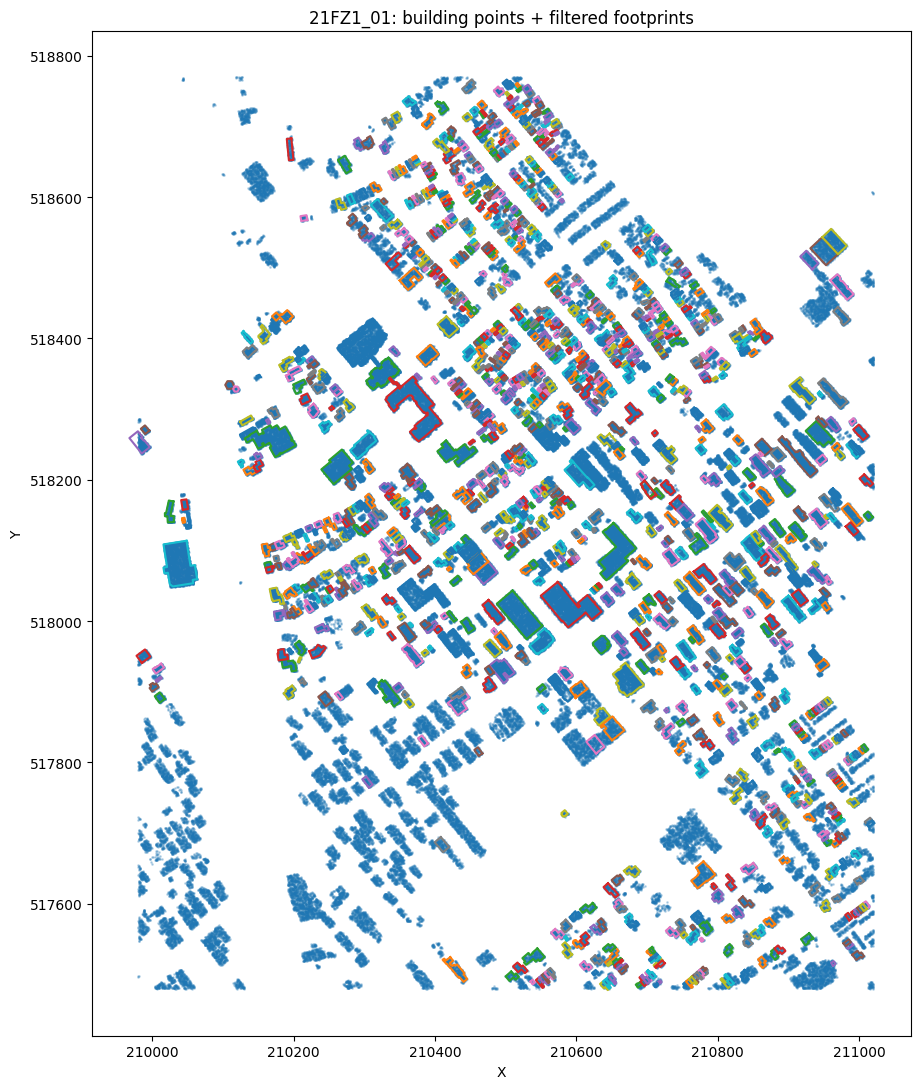

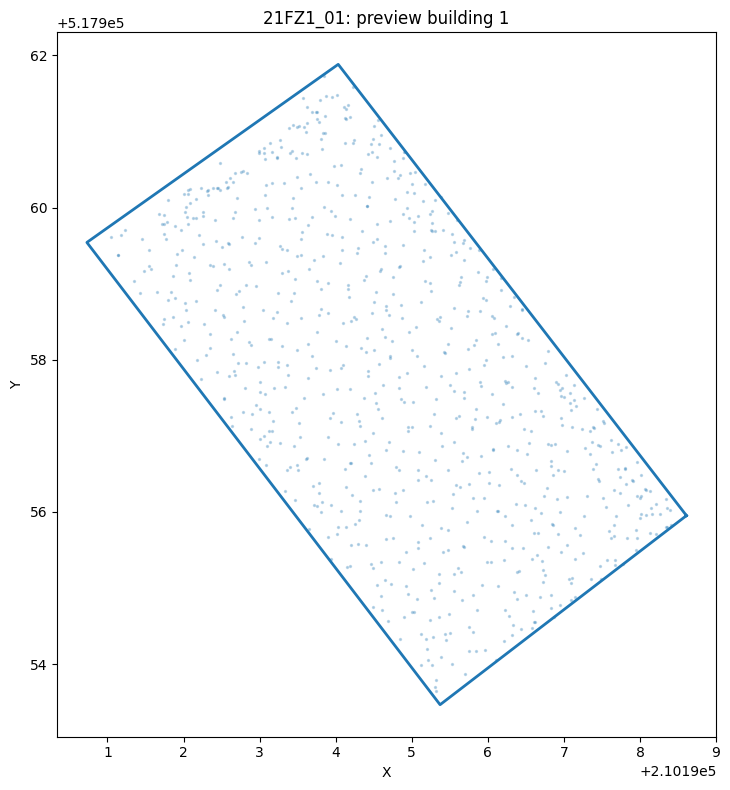

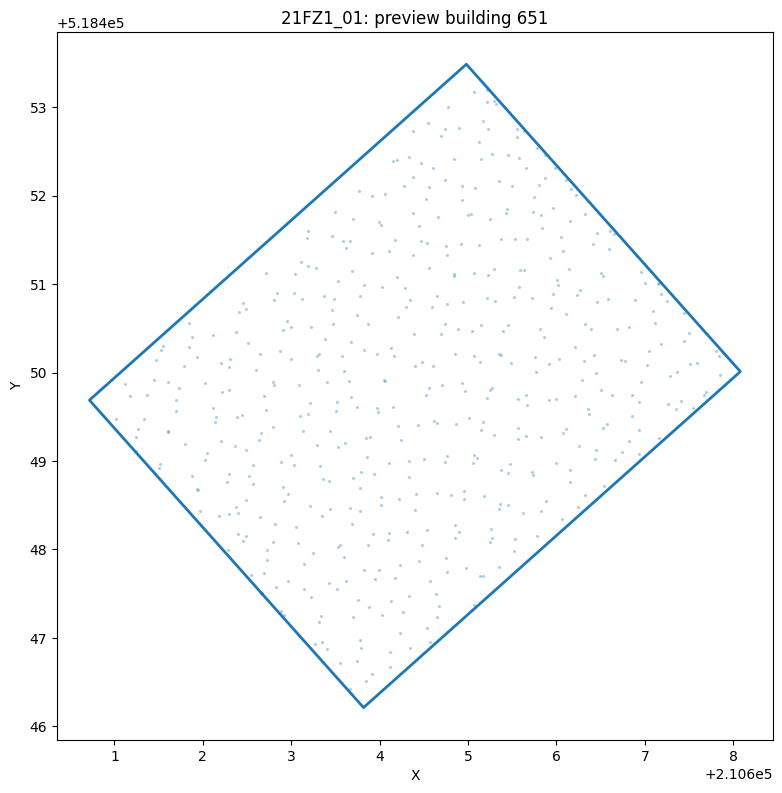

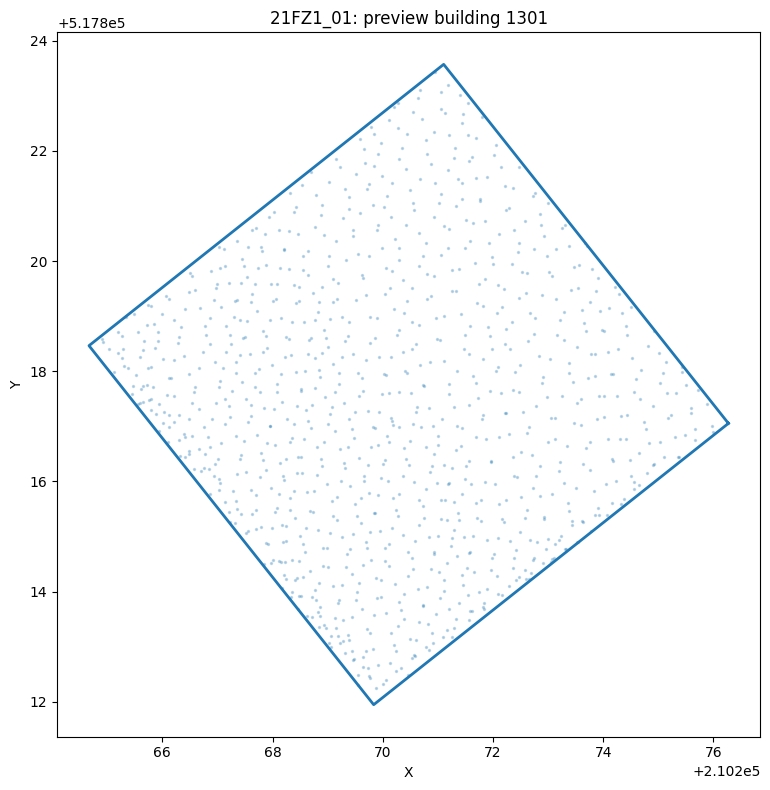

EXPORTING PER-BUILDING FILES
Using thread pool with 8 workers...


Buildings:   0%|          | 0/1301 [00:00<?, ?it/s]

Export time: 29.73 s
Export log saved to: D:\Saqib\Footprint_Extraction\GroundTruth\refine_files_building_extraction_pipeline\matched_buildings_21FZ1_01\export_log.csv
SUMMARY
Tile:                     21FZ1_01
Output directory:         D:\Saqib\Footprint_Extraction\GroundTruth\refine_files_building_extraction_pipeline\matched_buildings_21FZ1_01
Original footprints:      5,546
Filtered footprints:      2,116
Valid footprints:         1,301
Exported buildings:       1,301
Empty buildings:          0
Total exported points:    3,269,124
Total pipeline time:      51.44 s


,building_name,source_index,status,points,density,las_file,shp_file,gpkg_file
0,building_001,0,exported,844,27.428277,building_001.las,building_001.shp,building_001.gpkg
1,building_002,1,exported,1527,21.652416,building_002.las,building_002.shp,building_002.gpkg
2,building_003,2,exported,2879,19.725829,building_003.las,building_003.shp,building_003.gpkg
3,building_004,3,exported,5548,25.018976,building_004.las,building_004.shp,building_004.gpkg
4,building_005,4,exported,3436,26.709365,building_005.las,building_005.shp,building_005.gpkg


In [6]:
def run_one_tile_pipeline(tile_path):
    """
    End-to-end processing for one LAZ tile.
    The final output is a folder containing one file set per building.
    """
    t0 = time.perf_counter()
    tile_name = os.path.splitext(os.path.basename(tile_path))[0]
    output_dir = prepare_output_dir(tile_name)
    print("=" * 90)
    print(f"PROCESSING TILE: {tile_name}")
    print("=" * 90)
    # ------------------------------------------------------------------
    # Load tile
    # ------------------------------------------------------------------
    t_load = time.perf_counter()
    las, x, y, z = load_tile_laz(tile_path)
    tile_bbox = {
        "minx": float(las.header.x_min),
        "miny": float(las.header.y_min),
        "maxx": float(las.header.x_max),
        "maxy": float(las.header.y_max),
    }
    print(f"Tile load time: {time.perf_counter() - t_load:.2f} s")
    # ------------------------------------------------------------------
    # Load footprints for this tile
    # ------------------------------------------------------------------
    t_fp = time.perf_counter()
    footprints_raw = load_footprints_for_tile(MASTER_GPKG, tile_bbox, buffer_m=GPKG_BBOX_BUFFER_M)
    if footprints_raw.empty:
        raise RuntimeError("No footprints were found near this tile.")
    footprints = filter_footprints_for_tile(footprints_raw, tile_bbox)
    if footprints.empty:
        raise RuntimeError("No footprints survived the spatial / temporal / status filters.")
    print(f"Footprints after filtering: {len(footprints):,}")
    print(f"Footprint load/filter time: {time.perf_counter() - t_fp:.2f} s")
    # Optional ID report
    id_candidates = [
        "pandidentificatie", "identificatie", "building_id", "id",
        "gml_id", "gmlid", "name", "naam", "identifier"
    ]
    id_col = next((c for c in id_candidates if c in footprints.columns), None)
    if id_col is not None:
        print(f"Detected footprint ID column: {id_col}")
        print(f"Unique IDs in filtered set: {footprints[id_col].astype(str).nunique():,}")
    # ------------------------------------------------------------------
    # Keep building-class points only
    # ------------------------------------------------------------------
    print(f"Filtering tile to building points (class {CLASS_BUILDINGS})...")
    t_pts = time.perf_counter()
    building_mask = las.classification == CLASS_BUILDINGS
    las_buildings = las[building_mask]
    print(f"  Building points kept: {len(las_buildings):,}")
    if len(las_buildings) == 0:
        raise RuntimeError("No building-class points were found in this tile.")
    print(f"Point filter time: {time.perf_counter() - t_pts:.2f} s")
    # Shared point counter with optional count cache
    point_counter = PolygonPointCounter(np.asarray(las_buildings.x), np.asarray(las_buildings.y), enabled=USE_COUNT_CACHE)
    # ------------------------------------------------------------------
    # Estimate density threshold
    # ------------------------------------------------------------------
    t_density = time.perf_counter()
    avg_density, density_threshold = estimate_density_threshold(
        las_buildings,
        footprints,
        sample_size=DENSITY_SAMPLE_SIZE,
        min_area=MIN_FOOTPRINT_AREA_M2,
        point_counter=point_counter,
    )
    print(f"Average sampled density: {avg_density:.3f} pts/m²")
    print(f"Density threshold (80%):  {density_threshold:.3f} pts/m²")
    if ENABLE_DENSITY_FILTER:
        valid_footprints = apply_density_filter(
            footprints,
            las_buildings,
            threshold=density_threshold,
            min_area=MIN_FOOTPRINT_AREA_M2,
            point_counter=point_counter,
        )
        print(f"Footprints after density filter: {len(valid_footprints):,}")
    else:
        valid_footprints = footprints.copy()
        valid_footprints["density"] = np.nan
        print("Density filter is disabled; all filtered footprints will be exported.")
    if valid_footprints.empty:
        raise RuntimeError("No footprints survived the density filter.")
    print(f"Density work time: {time.perf_counter() - t_density:.2f} s")
    # ------------------------------------------------------------------
    # Quick preview plots before export
    # ------------------------------------------------------------------
    if ENABLE_PREVIEW_PLOTS:
        print("Generating preview plot...")
        plot_tile_preview(
            las_buildings=las_buildings,
            footprints=valid_footprints,
            max_points=PREVIEW_MAX_POINTS,
            title=f"{tile_name}: building points + filtered footprints",
        )
        sample_ids = _build_preview_sample_indices(len(valid_footprints), PREVIEW_SAMPLE_BUILDINGS)
        for sid in sample_ids:
            row = valid_footprints.iloc[sid]
            preview_pts, _, _ = build_building_point_cloud(las_buildings, row.geometry, point_counter=point_counter)
            if preview_pts is not None and len(preview_pts) > 0:
                plot_building_validation(
                    preview_pts,
                    row.geometry,
                    title=f"{tile_name}: preview building {sid + 1}",
                    max_points=20_000,
                )
    # ------------------------------------------------------------------
    # Export each building into the output folder
    # ------------------------------------------------------------------
    print("=" * 90)
    print("EXPORTING PER-BUILDING FILES")
    print("=" * 90)
    export_rows = []
    def _process_one_export(i, idx, row):
        building_name = f"building_{i:03d}"
        row_dict = _row_to_dict(row)
        polygon = row.geometry
        density_value = row_dict.get("density", np.nan)
        las_building, point_count, _ = build_building_point_cloud(las_buildings, polygon, point_counter=point_counter)
        if las_building is None or point_count == 0:
            return {
                "building_name": building_name,
                "source_index": int(idx),
                "status": "empty",
                "points": 0,
                "density": density_value,
                "las_file": None,
                "shp_file": None,
                "gpkg_file": None,
            }
        las_path, shp_path, gpkg_path = export_single_building(
            output_dir=output_dir,
            building_name=building_name,
            las_building=las_building,
            footprint_row_dict=row_dict,
            source_index=int(idx),
            density_value=density_value,
            crs=valid_footprints.crs,
        )
        return {
            "building_name": building_name,
            "source_index": int(idx),
            "status": "exported",
            "points": int(point_count),
            "density": float(density_value) if density_value is not None and not pd.isna(density_value) else np.nan,
            "las_file": os.path.basename(las_path) if EXPORT_LAS else None,
            "shp_file": os.path.basename(shp_path) if EXPORT_SHP else None,
            "gpkg_file": os.path.basename(gpkg_path) if EXPORT_GPKG else None,
        }
    t_export = time.perf_counter()
    rows_iter = list(valid_footprints.iterrows())
    if PARALLEL_BUILDING_EXPORT and len(rows_iter) > 1:
        print(f"Using thread pool with {EXPORT_WORKERS} workers...")
        with ThreadPoolExecutor(max_workers=EXPORT_WORKERS) as ex:
            futures = {
                ex.submit(_process_one_export, i, idx, row): (i, idx)
                for i, (idx, row) in enumerate(rows_iter, start=1)
            }
            for fut in tqdm(as_completed(futures), total=len(futures), desc="Buildings"):
                export_rows.append(fut.result())
    else:
        for i, (idx, row) in enumerate(tqdm(rows_iter, total=len(rows_iter), desc="Buildings"), start=1):
            export_rows.append(_process_one_export(i, idx, row))
    export_log = pd.DataFrame(export_rows).sort_values("building_name").reset_index(drop=True)
    print(f"Export time: {time.perf_counter() - t_export:.2f} s")
    # ------------------------------------------------------------------
    # Save log and print summary
    # ------------------------------------------------------------------
    if EXPORT_LOG_CSV:
        log_path = os.path.join(output_dir, "export_log.csv")
        export_log.to_csv(log_path, index=False)
        print(f"Export log saved to: {log_path}")
    exported = int((export_log["status"] == "exported").sum())
    empty = int((export_log["status"] == "empty").sum())
    total_points = int(export_log.loc[export_log["status"] == "exported", "points"].sum())
    print("=" * 90)
    print("SUMMARY")
    print("=" * 90)
    print(f"Tile:                     {tile_name}")
    print(f"Output directory:         {output_dir}")
    print(f"Original footprints:      {len(footprints_raw):,}")
    print(f"Filtered footprints:      {len(footprints):,}")
    print(f"Valid footprints:         {len(valid_footprints):,}")
    print(f"Exported buildings:       {exported:,}")
    print(f"Empty buildings:          {empty:,}")
    print(f"Total exported points:    {total_points:,}")
    print(f"Total pipeline time:      {time.perf_counter() - t0:.2f} s")
    print("=" * 90)
    # ------------------------------------------------------------------
    # Optional renumbering step
    # ------------------------------------------------------------------
    if ENABLE_RENUMBERING:
        renumber_output_files(output_dir, start_number=RENUMBER_START_NUMBER)
    return export_log, output_dir, valid_footprints, las_buildings
# -------------------------------------------------------------------
# Build / reuse cache first
# -------------------------------------------------------------------
ensure_footprint_cache(BUILDING_XML_DIR, MASTER_GPKG)
# -------------------------------------------------------------------
# Run the pipeline
# -------------------------------------------------------------------
export_log, final_output_dir, valid_footprints, las_buildings = run_one_tile_pipeline(TILE_LAZ_FILE)
export_log.head()

## Optional inspection cells

Use these after the main run to inspect the export log or visualize a specific building.

In [15]:
# Summary tables
display(export_log.head(20))
display(export_log["status"].value_counts(dropna=False).to_frame("count"))

,building_name,source_index,status,points,density,las_file,shp_file,gpkg_file
0,building_001,0,exported,2556,16.154005,building_001.las,building_001.shp,building_001.gpkg
1,building_002,1,exported,3605,16.179436,building_002.las,building_002.shp,building_002.gpkg
2,building_003,2,exported,1649,13.613139,building_003.las,building_003.shp,building_003.gpkg
3,building_004,3,exported,1162,14.831302,building_004.las,building_004.shp,building_004.gpkg
4,building_005,4,exported,1876,14.451304,building_005.las,building_005.shp,building_005.gpkg
5,building_006,5,exported,1683,15.338566,building_006.las,building_006.shp,building_006.gpkg
6,building_007,6,exported,2330,16.956978,building_007.las,building_007.shp,building_007.gpkg
7,building_008,7,exported,654,11.713468,building_008.las,building_008.shp,building_008.gpkg
8,building_009,8,exported,5214,15.932395,building_009.las,building_009.shp,building_009.gpkg
9,building_010,9,exported,4540,16.601173,building_010.las,building_010.shp,building_010.gpkg


,count
status,
exported,1541


First exported building:
building_name         building_001
source_index                     0
status                    exported
points                        2556
density                  16.154005
las_file          building_001.las
shp_file          building_001.shp
gpkg_file        building_001.gpkg
Name: 0, dtype: object


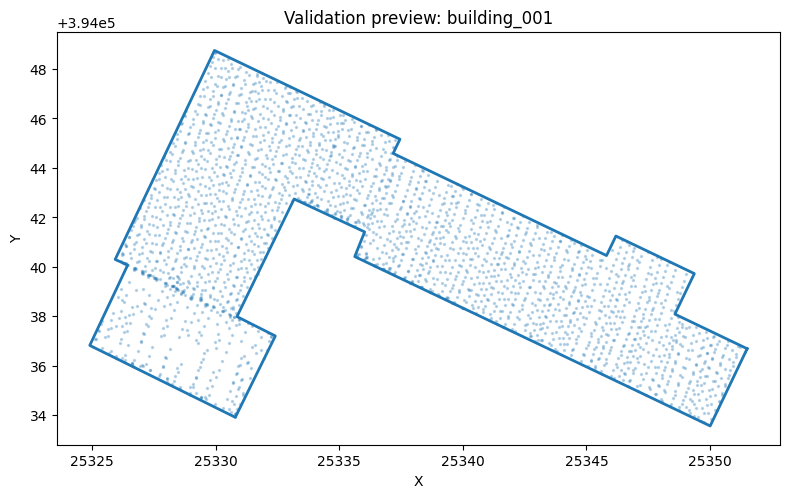

In [16]:
# Example: preview a specific exported building after the run
exported_rows = export_log[export_log["status"] == "exported"].copy()
if len(exported_rows) > 0:
    first_building = exported_rows.iloc[0]
    first_name = first_building["building_name"]
    las_file = os.path.join(final_output_dir, f"{first_name}.las")
    print("First exported building:")
    print(first_building)
    if os.path.exists(las_file):
        preview_las = laspy.read(las_file)
        idx_num = int(first_name.split("_")[1]) - 1
        if 0 <= idx_num < len(valid_footprints):
            plot_building_validation(
                preview_las,
                valid_footprints.iloc[idx_num].geometry,
                title=f"Validation preview: {first_name}",
                max_points=20_000,
            )